In [1]:
import matplotlib.pyplot as plt
from packaging.tags import platform_tags
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import pandas as pd

data = pd.read_csv('./../data/IoT_data.csv')
data.head()

,Unnamed: 0,Temperature,Humidity,Device_Usage,Signal_Strength,Anomaly
0,0,24.363503,67.089210,96,3,0
1,1,38.767858,75.767698,0,5,1
2,2,33.299849,37.532753,50,3,0
3,3,29.966462,63.741187,4,3,0
4,4,18.900466,60.022219,12,2,0


In [2]:
X = data[['Temperature', 'Humidity','Device_Usage','Signal_Strength']]
y = data['Anomaly']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=100)
dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)
print(accuracy_score(y_test, dt_predictions))
print(classification_report(y_test, dt_predictions))
print(confusion_matrix(y_test, dt_predictions))

0.7333333333333333
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       510
           1       0.16      0.19      0.18        90

    accuracy                           0.73       600
   macro avg       0.51      0.51      0.51       600
weighted avg       0.75      0.73      0.74       600

[[423  87]
 [ 73  17]]


In [4]:
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
print(accuracy_score(y_test, rf_predictions))
print(classification_report(y_test, rf_predictions))
print(confusion_matrix(y_test, rf_predictions))

0.8416666666666667
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       510
           1       0.14      0.01      0.02        90

    accuracy                           0.84       600
   macro avg       0.50      0.50      0.47       600
weighted avg       0.74      0.84      0.78       600

[[504   6]
 [ 89   1]]


Comparison of dt and rfc


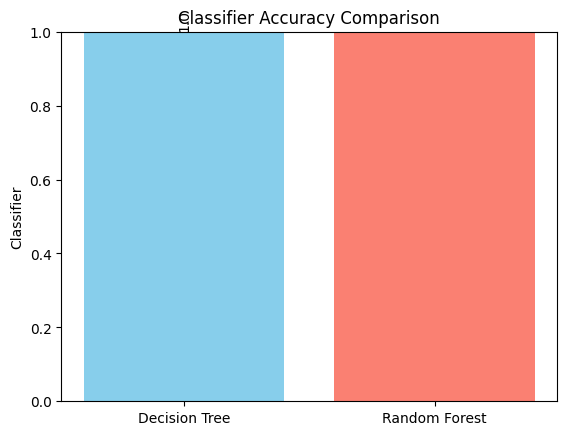

In [6]:
print('Comparison of dt and rfc')
import matplotlib.pyplot as plt
import seaborn as sns

comparison_df = pd.DataFrame({
    'Classifier': ['Decision Tree', 'Random Forest'],
    "Accuracy": [dt_model.score(X_train, y_train), rf_model.score(X_train, y_train)]
})

fig, ax = plt.subplots()
bars = ax.bar(comparison_df['Classifier'], comparison_df['Accuracy'], color=['skyblue','salmon'])

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            bar.get_height(), ha='center', va='bottom', rotation=90)
    ax.set_title('Classifier Accuracy Comparison')
    ax.set_ylabel('Classifier')
    ax.set_ylim(0,1)

    plt.show()

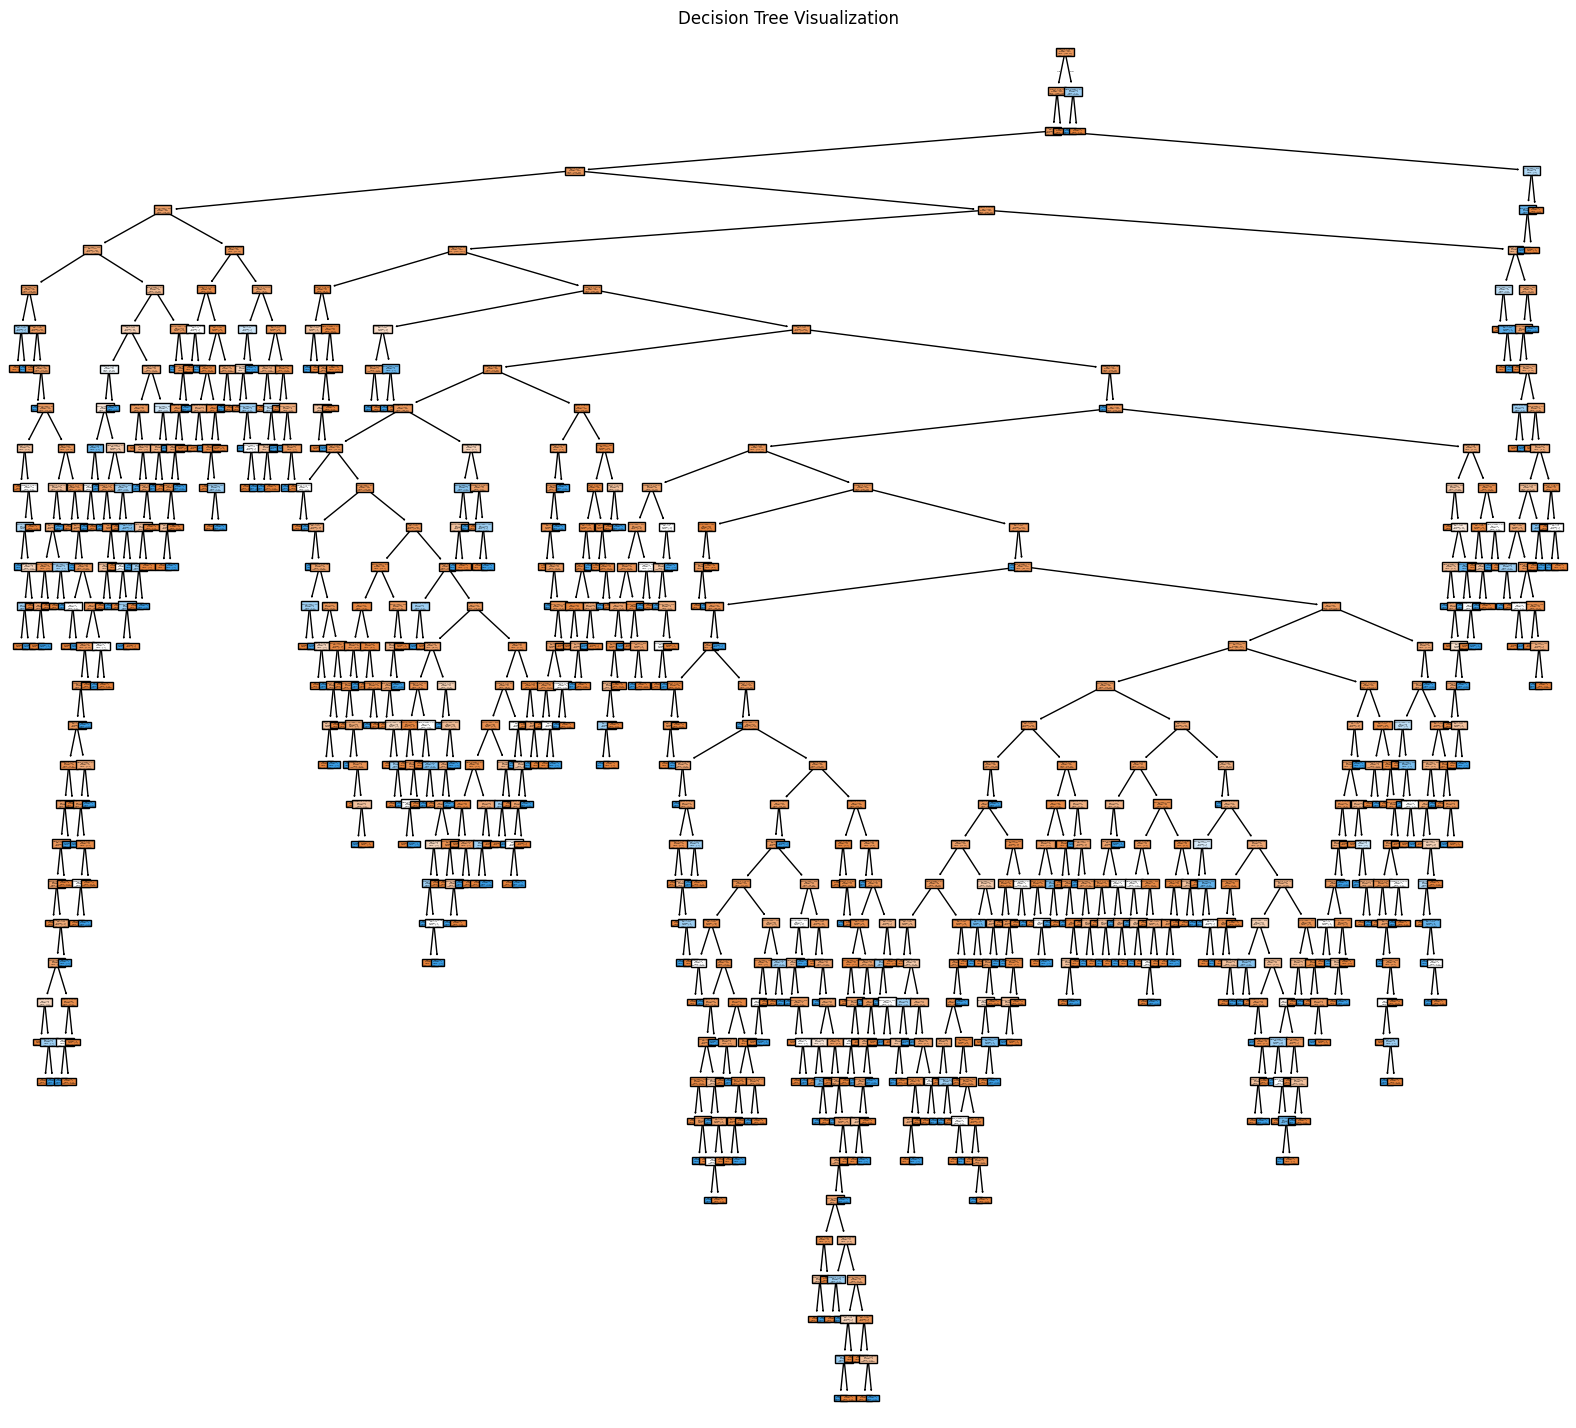

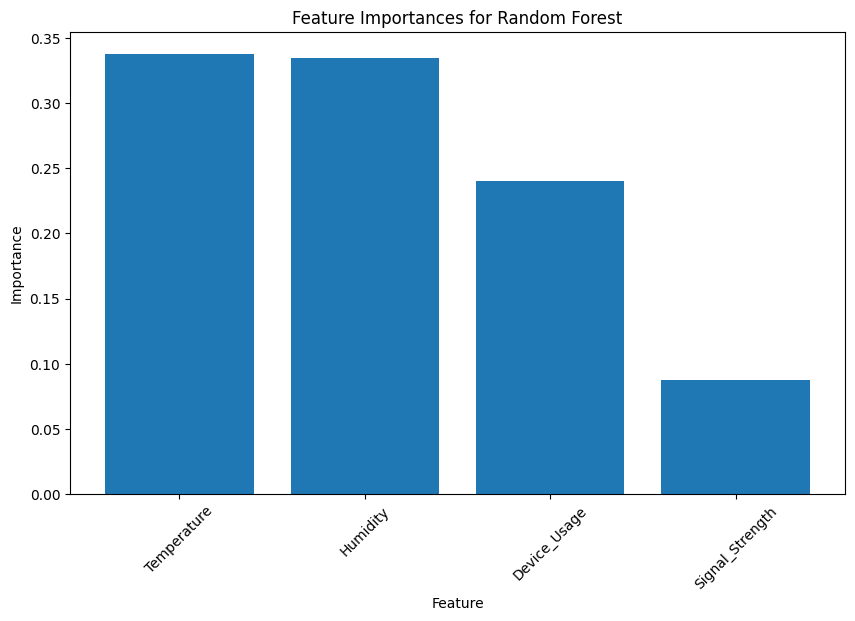

In [7]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np # Rastgele Orman kısmı için gerekli

# --- Karar Ağacı Görselleştirme ---
# Not: 'dt_model', X, 'No Anomaly', 'Anomaly' değişkenlerinin daha önce tanımlanmış olması gerekir.

plt.figure(figsize=(20, 18))
# dt_model: Eğitilmiş Karar Ağacı modeli
# feature_names=X.columns: Veri setindeki öznitelik isimleri
# class_names=['No Anomaly', 'Anomaly']: Sınıf isimleri
# filled=True: Düğümleri sınıfa göre renklendirir
plot_tree(dt_model, feature_names=X.columns, class_names=['No Anomaly', 'Anomaly'], filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# --- Rastgele Orman Öznitelik Önemleri ---
# Not: 'rf_model' değişkeninin daha önce tanımlanmış olması gerekir.

# Rastgele Orman modelinden öznitelik önemlerini al
importances = rf_model.feature_importances_

# Önemleri azalan sıraya göre sıralayan indeksleri bul
# [::-1] dilimlemesi, azalan sıraya göre (en önemliden en önemsize) sıralar.
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances for Random Forest")

# Çubuk grafiği oluşturma
# range(X.shape[1]): Grafikteki çubukların pozisyonları (öznitelik sayısı kadar)
# importances[indices]: Sıralanmış önem değerleri
# align='center': Çubukları ortala
plt.bar(range(X.shape[1]), importances[indices], align="center")

# X ekseni etiketlerini (öznitelik isimlerini) ayarlama
# [X.columns[i] for i in indices]: Sıralanmış indekse göre öznitelik isimleri
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=45)

plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()